### RaschPy PCM worked example

This notebook works through a sample Rasch analysis of a simulated data set (1,000 persons, 10 items - 4 with a maximum score of 5 and 6 with a maximum score of 3, and no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.PCM_Sim(no_of_items=10, no_of_persons=80, max_score_vector=[4] * 10, seed=108)
responses_disconnected = sim_disconnected.responses.copy()
responses_disconnected.iloc[:40, 5:] = float('nan')   # first 40 persons: only answer items 1-5
responses_disconnected.iloc[40:, :5] = float('nan')    # last 40 persons: only answer items 6-10

broken_pcm = rp.PCM(responses_disconnected, [4] * 10)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:161: UserWarning: max_score_vector['Item_4']=4 exceeds the maximum observed score (3) for that item. Some score categories may be unobserved.
  warnings.warn(
/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:161: UserWarning: max_score_vector['Item_5']=4 exceeds the maximum observed score (3) for that item. Some score categories may be unobserved.
  warnings.warn(
/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:225: UserWarning: 4 item(s) have a structurally unresolvable zero in calibrate()'s directed pairwise matrix: ['Item_1', 'Item_10', 'Item_4', 'Item_5']. This can silently corrupt calibration (NaN/overflow) even when the item(s) otherwise appear connected. Consider dropping these items or gathering more responses before calibrating.
  self.connectivity_status = self.check_data_connectivity()
/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:225: UserWarning: The data is split into 2 disconnect

`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_pcm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4', 'Item_5'],
  ['Item_6', 'Item_7', 'Item_8', 'Item_9', 'Item_10']],
 'directionally_isolated_items': ['Item_1', 'Item_10', 'Item_4', 'Item_5'],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 10 items, 1,000 persons, 20% missing data (so each person responds to ~8 items and each item has ~800 responses).

In [4]:
max_score_vector = [5, 5, 5, 5, 3, 3, 3, 3, 3, 3]
sim = rp.PCM_Sim(no_of_items=10, no_of_persons=1000, max_score_vector=max_score_vector, 
                 category_base=1.5, person_sd=2.5, missing=0, seed=999)
sim.responses.to_csv('pcm_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_pcm()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_pcm('pcm_scores.csv', max_score_vector=max_score_vector)

Check the data - view the first two lines

In [6]:
data.head(2)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10
Person_1,4.0,4.0,4.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0
Person_2,0.0,2.0,3.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0


Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10


Create a PCM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `pcm.generating`, which lets us check parameter recovery further down, and also means `max_score_vector` doesn't need to be supplied again. If you're analysing your own data, pass a DataFrame and `max_score_vector` instead (e.g. `rp.PCM(data, max_score_vector)`).

In [8]:
pcm = rp.PCM(sim)

Generate item estimates. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
pcm.calibrate()

CPU times: user 5.45 ms, sys: 388 μs, total: 5.84 ms
Wall time: 5.7 ms


Check the central item location estimates - view the first two items

In [10]:
pcm.items.head(2)

Item_1    0.619656
Item_2   -0.927457
dtype: float64

Since this is simulated data, we know the true generating item locations (`pcm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


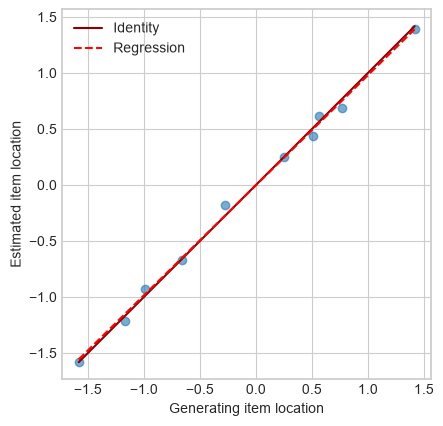

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 0.984
item location regression coefficient:            0.983
item location RMSE:                              0.056


In [12]:
recovery_plot(pcm.generating.items, pcm.items, 'item location', 'my_pcm_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
pcm.item_stats_df(full=True)
pcm.item_stats.to_csv('pcm_item_stats.csv')

CPU times: user 3.51 s, sys: 56.1 ms, total: 3.57 s
Wall time: 3.57 s


Check the item statistics table

In [14]:
pcm.item_stats

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.620,0.044,0.538,0.713,1000,0.438,0.844,-3.355,0.787,-3.654,0.879,0.862
Item_2,-0.927,0.073,-1.080,-0.800,1000,0.581,0.881,-2.762,0.881,-2.779,0.838,0.822
Item_3,0.684,0.045,0.600,0.776,1000,0.433,0.844,-3.262,0.815,-2.547,0.876,0.860
Item_4,1.394,0.062,1.291,1.535,1000,0.374,0.862,-3.158,0.863,-2.864,0.848,0.830
Item_5,-1.578,0.062,-1.700,-1.450,1000,0.681,0.900,-2.146,0.857,-1.769,0.795,0.776
Item_6,0.439,0.047,0.347,0.525,1000,0.440,0.871,-2.586,0.778,-2.415,0.832,0.813
Item_7,-1.213,0.062,-1.337,-1.105,1000,0.640,0.888,-2.335,0.823,-1.776,0.813,0.794
Item_8,0.246,0.048,0.159,0.345,1000,0.461,0.856,-3.061,0.817,-2.534,0.833,0.814
Item_9,-0.666,0.054,-0.774,-0.570,1000,0.584,0.873,-2.847,0.845,-2.812,0.821,0.796
Item_10,-0.180,0.052,-0.276,-0.082,1000,0.528,0.962,-0.805,0.960,-0.626,0.815,0.810


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
pcm.threshold_stats_df(full=True)
pcm.threshold_stats.to_csv('pcm_threshold_stats_centred.csv')
pcm.threshold_stats_uncentred.to_csv('pcm_threshold_stats_uncentred.csv')

CPU times: user 5.47 ms, sys: 966 μs, total: 6.44 ms
Wall time: 6.27 ms


Check the centred threshold statistics table - view the first two thresholds

In [16]:
pcm.threshold_stats.head(2)

Estimate     SE   2.5%  97.5%  Infit MS  Infit Z  Outfit MS  \
Item_1 1    -1.973  0.134 -2.223 -1.699     0.998   -0.015      0.899   
       2    -1.262  0.135 -1.521 -1.021     0.876   -2.469      0.828   

          Outfit Z  Discrim  PM corr  Exp PM corr  
Item_1 1    -0.810    1.030    0.175        0.169  
       2    -2.375    1.373    0.122        0.097

Check the uncentred threshold statistics table - view the first two items

In [17]:
pcm.threshold_stats_uncentred.head(2)

Estimate     SE   2.5%  97.5%  Infit MS  Infit Z  Outfit MS  \
Item_1 1    -1.353  0.134 -1.603 -1.079     0.998   -0.015      0.899   
       2    -0.642  0.135 -0.901 -0.401     0.876   -2.469      0.828   

          Outfit Z  Discrim  PM corr  Exp PM corr  
Item_1 1    -0.810    1.030    0.175        0.169  
       2    -2.375    1.373    0.122        0.097

And the same recovery check for the uncentred threshold structure, against `pcm.generating.thresholds_uncentred`. Since thresholds are per-item, we flatten (item, threshold) pairs into a single series with `.unstack()` first:

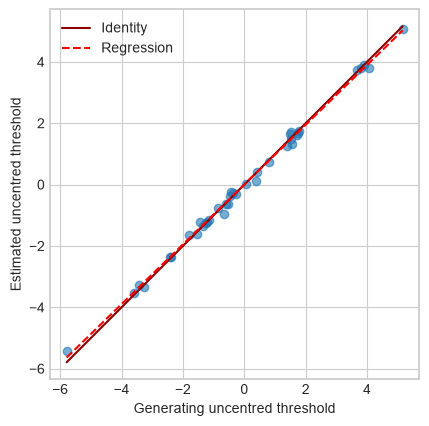

uncentred threshold Pearson correlation:              0.999
uncentred threshold SD ratio (estimated / generating): 0.975
uncentred threshold regression coefficient:            0.974
uncentred threshold RMSE:                              0.138


In [18]:
orig_thresholds = pcm.generating.thresholds_uncentred.unstack().dropna()
est_thresholds = pcm.thresholds_uncentred.unstack().dropna()
recovery_plot(orig_thresholds, est_thresholds, 'uncentred threshold', 'my_pcm_threshold_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [19]:
%%time
pcm.person_stats_df(full=True)
pcm.person_stats.to_csv('pcm_person_stats.csv')

CPU times: user 9.5 ms, sys: 1.41 ms, total: 10.9 ms
Wall time: 10.4 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [20]:
pcm.person_stats.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Infit Z,Outfit MS,Outfit Z
Person_1,2.391,0.567,0.364,31,38,0.816,0.410,-1.281,0.469,-0.881
Person_2,-1.393,0.425,0.530,11,38,0.289,1.556,1.226,1.215,0.602
Person_3,-5.015,1.031,0.402,1,38,0.026,0.152,-1.305,0.083,-0.282
Person_4,0.160,0.409,0.495,21,38,0.553,1.463,1.048,1.311,0.784
Person_5,1.805,0.516,0.533,29,38,0.763,1.065,0.294,0.916,0.003
Person_6,-0.608,0.391,0.261,16,38,0.421,0.443,-1.646,0.459,-1.540
Person_7,-0.311,0.394,0.219,18,38,0.474,0.310,-2.181,0.315,-2.141
Person_8,-1.775,0.459,0.375,9,38,0.237,0.668,-0.632,0.612,-0.753
Person_9,1.314,0.478,0.429,27,38,0.711,0.805,-0.278,0.768,-0.377
Person_10,-2.510,0.542,0.574,6,38,0.158,1.122,0.397,1.085,0.341


And the same recovery check for person locations, against `pcm.generating.persons`:

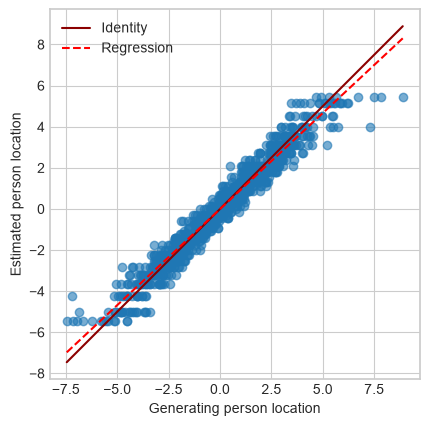

person location Pearson correlation:              0.974
person location SD ratio (estimated / generating): 0.96
person location regression coefficient:            0.935
person location RMSE:                              0.56


In [21]:
recovery_plot(pcm.generating.persons, pcm.persons, 'person location', 'my_pcm_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [22]:
%%time
pcm.test_stats_df()
pcm.test_stats.to_csv('pcm_test_stats.csv')

CPU times: user 1.02 ms, sys: 562 μs, total: 1.58 ms
Wall time: 1.5 ms


Check the test statistics table

In [23]:
pcm.test_stats

,Items,Thresholds,Persons
Mean,-0.118,-0.000,-0.007
SD,0.955,2.263,2.366
Separation ratio,17.167,15.491,4.738
Strata,23.222,20.988,6.650
Reliability,0.997,0.996,0.957


Run a residual correlation analysis (and check run time), and save relevant output to file

In [24]:
%%time
pcm.res_corr_analysis()
pcm.residual_correlations.to_csv('pcm_residual_correlations.csv')
pcm.loadings.to_csv('pcm_loadings.csv')

CPU times: user 7.6 ms, sys: 2.3 ms, total: 9.9 ms
Wall time: 11.2 ms


View the table of pairwise standard residual correlations

In [25]:
round(pcm.residual_correlations, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10
Item_1,1.000,-0.085,-0.195,-0.083,-0.153,-0.157,-0.132,-0.143,-0.124,-0.096
Item_2,-0.085,1.000,-0.132,-0.093,-0.116,-0.090,-0.138,-0.106,-0.101,-0.115
Item_3,-0.195,-0.132,1.000,-0.190,-0.114,-0.096,-0.062,-0.144,-0.112,-0.122
Item_4,-0.083,-0.093,-0.190,1.000,-0.096,-0.140,-0.104,-0.055,-0.105,-0.129
Item_5,-0.153,-0.116,-0.114,-0.096,1.000,-0.097,-0.095,-0.004,-0.095,-0.078
Item_6,-0.157,-0.090,-0.096,-0.140,-0.097,1.000,-0.092,-0.132,-0.061,-0.096
Item_7,-0.132,-0.138,-0.062,-0.104,-0.095,-0.092,1.000,-0.094,-0.083,-0.108
Item_8,-0.143,-0.106,-0.144,-0.055,-0.004,-0.132,-0.094,1.000,-0.097,-0.149
Item_9,-0.124,-0.101,-0.112,-0.105,-0.095,-0.061,-0.083,-0.097,1.000,-0.094
Item_10,-0.096,-0.115,-0.122,-0.129,-0.078,-0.096,-0.108,-0.149,-0.094,1.000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [26]:
round(pcm.loadings['PC 1'], 3)

Item_1    -0.170
Item_2    -0.041
Item_3     0.250
Item_4    -0.228
Item_5     0.024
Item_6     0.121
Item_7     0.073
Item_8    -0.086
Item_9     0.024
Item_10    0.047
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the thresholds marked

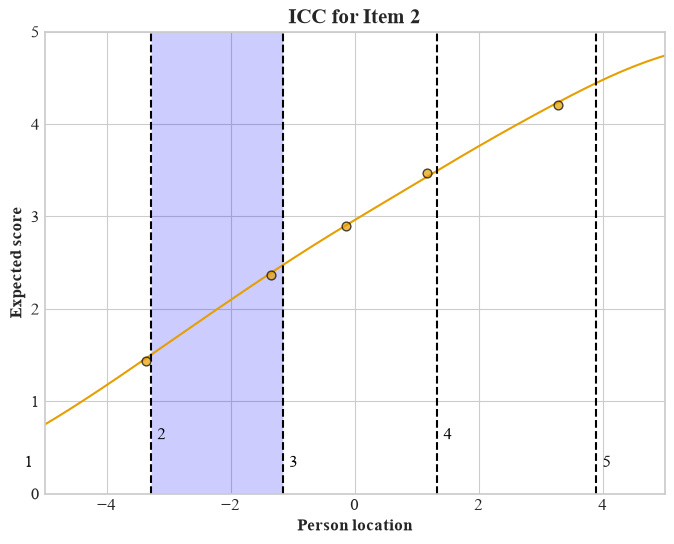

In [27]:
pcm.icc('Item_2', title='ICC for Item 2', obs=True, thresh_lines=True, cat_highlight=2, xmin=-5, xmax=5, filename='my_pcm_icc')

Produce category response curves for Item 2, with the central item location marked

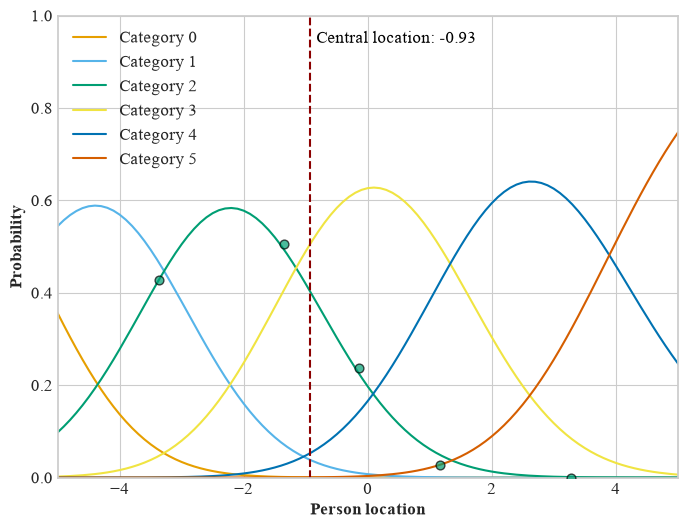

In [28]:
pcm.crcs('Item_2', central_location=True, obs=[2], xmin=-5, xmax=5, filename='my_pcm_crcs')

Produce threshold characteristic curves for Item 2, with observed category means plotted for threshold 2 and the central item location marked

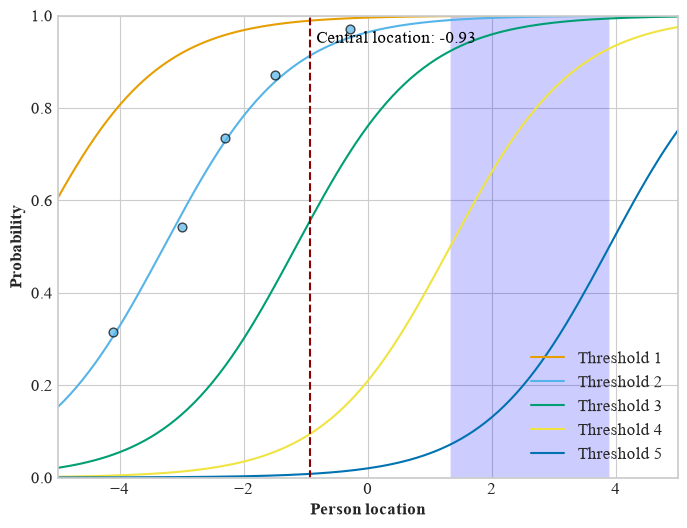

In [29]:
pcm.threshold_ccs('Item_2', central_location=True, obs=[2], cat_highlight=4, xmin=-5, xmax=5, filename='my_pcm_threshold_ccs')

Produce an item information function curve for Item 2

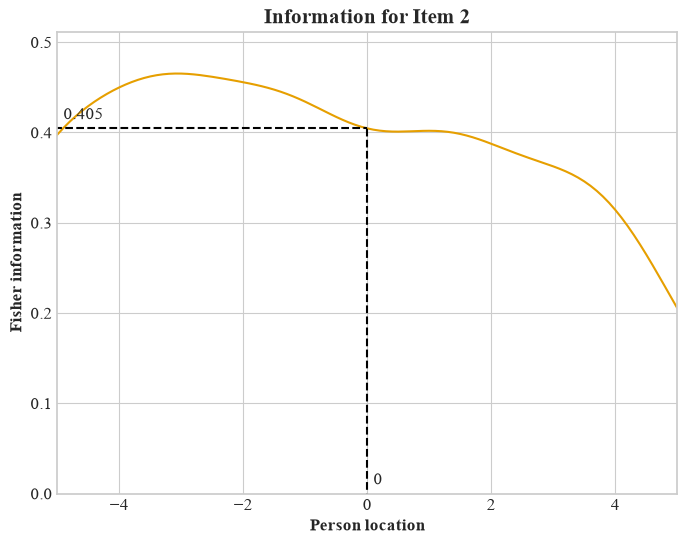

In [30]:
pcm.iic('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2', xmin=-5, xmax=5, filename='my_pcm_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 15 and 25 plotted.

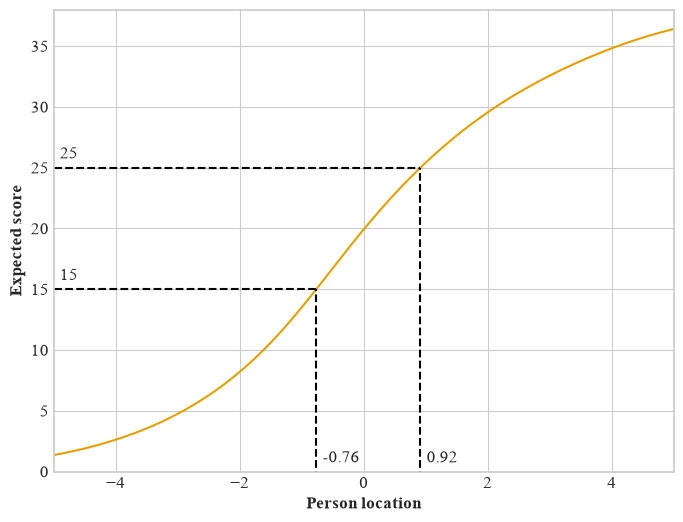

In [31]:
pcm.tcc(score_lines=[15, 25], score_labels=True, filename='my_pcm_tcc')

Produce a test information curve

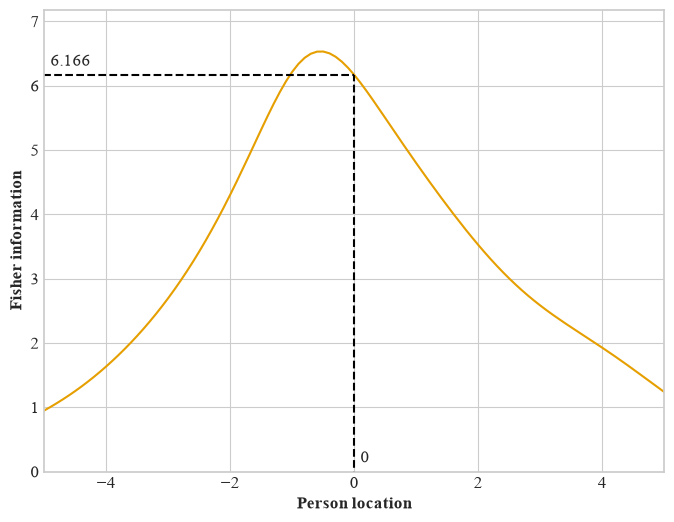

In [32]:
pcm.test_info(point_info_lines=[0], point_info_labels=True, filename='my_pcm_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

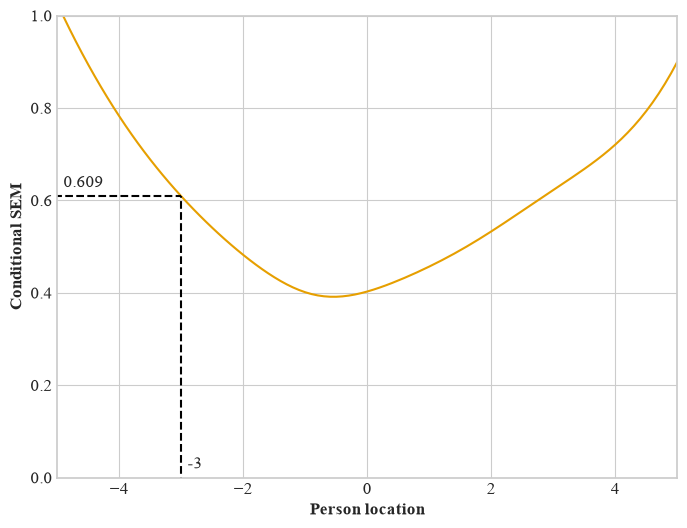

In [33]:
pcm.test_csem(point_csem_lines=[-3], point_csem_labels=True, ymax=1, filename='my_pcm_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

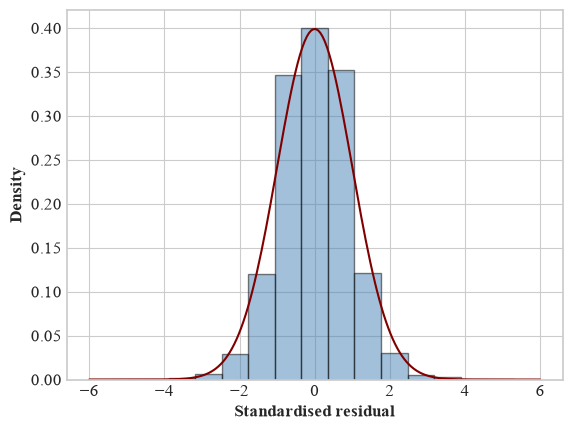

In [34]:
pcm.std_residuals_plot(bin_width=0.6, normal=True, filename='my_pcm_std_residuals_plot')

Produce a Wright map, showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold), with mean/±1SD/±2SD reference marks for persons

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/pcm.py:7402: UserWarning: Disordered thresholds for item(s) Item_3. Only categories that are most probable for some range of the trait shown. For more detailed inspection of threshold structure, run self.crcs() plot and/or self.threshold_stats_df().
  warnings.warn(


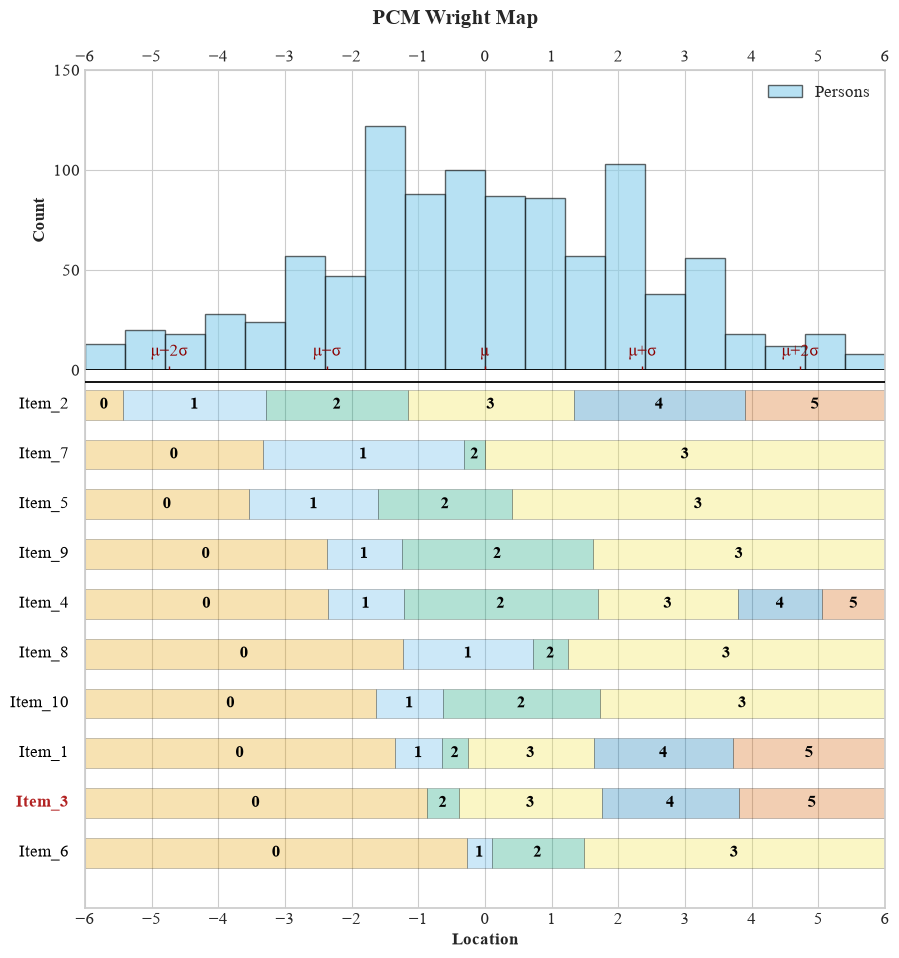

In [35]:
pcm.wright_map(item_strip=True, distribution_markers=True, title='PCM Wright Map', filename='my_pcm_wright_map')